Bag-of-Words and Skip-gram

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence

# Example sentences
sentences = [
    ["I", "love", "chocolate"],
    ["I", "love", "ice", "cream"],
    ["I", "enjoy", "playing", "tennis"]
]

# Create vocabulary
vocab = set([word for sentence in sentences for word in sentence])
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}
vocab_size = len(vocab)

# Generate training data
window_size = 4
train_data = []
for sentence in sentences:
    for i, target_word in enumerate(sentence):
        context_words = [sentence[j] for j in range(max(0, i - window_size), min(i + window_size + 1,len(sentence) )) if j>=0 and j != i]
        train_data.append((context_words, target_word))

print(train_data)

# Generate input and output pairs for CBOW
train_inputs, train_labels = [], []
for context_words, target_word in train_data:
    context_idxs = [word2idx[word] for word in context_words]
    train_inputs.append(torch.tensor(context_idxs, dtype=torch.long))
    train_labels.append(word2idx[target_word])

# Pad sequences to ensure uniform input length for batching
# Use pad_sequence for PyTorch, it pads to the longest sequence in the batch
# For CBOW, all context windows are usually fixed size, but if not, this handles it.
# Here we want to pad to `window_size * 2` based on the original Keras setup.
max_len_context = window_size * 2 # Based on the original Keras pad_sequences `maxlen`

def pad_to_maxlen(sequences, maxlen, padding_value=0):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < maxlen:
            padded_seq = torch.cat([seq, torch.full((maxlen - len(seq),), padding_value, dtype=torch.long)])
        else:
            padded_seq = seq[:maxlen]
        padded_sequences.append(padded_seq)
    return torch.stack(padded_sequences)

train_inputs_padded = pad_to_maxlen(train_inputs, maxlen=max_len_context, padding_value=word2idx.get('<pad>', 0))
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)

# Define CBOW model using PyTorch
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, inputs):
        # inputs shape: (batch_size, max_len_context)
        embedded = self.embedding(inputs)  # embedded shape: (batch_size, max_len_context, embedding_dim)
        # Sum the embeddings of the context words (average is also common)
        sum_embedded = embedded.sum(dim=1)  # sum_embedded shape: (batch_size, embedding_dim)
        output = self.linear(sum_embedded) # output shape: (batch_size, vocab_size)
        return output

embedding_dim = 10
cbow_model = CBOW(vocab_size, embedding_dim)

# Compile and train the CBOW model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cbow_model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = cbow_model(train_inputs_padded)
    loss = criterion(outputs, train_labels_tensor)
    loss.backward()
    optimizer.step()
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

# Get the learned word embeddings
word_embeddings = cbow_model.embedding.weight.data.numpy()

# Print the word embeddings
for i, embedding in enumerate(word_embeddings):
    if i < vocab_size: # Ensure we don't try to access out of bounds if padding was introduced
        word = idx2word[i]
        print(f"Word: {word}, Embedding: {embedding}")






from sklearn.metrics.pairwise import cosine_similarity

# Get embeddings for 'love' and 'chocolate' from the trained PyTorch model
embedding_love_idx = word2idx['love']
embedding_chocolate_idx = word2idx['chocolate']

embedding_love = word_embeddings[embedding_love_idx]
embedding_chocolate = word_embeddings[embedding_chocolate_idx]

similarity = cosine_similarity([embedding_love], [embedding_chocolate])
print(f"Cosine similarity between 'love' and 'chocolate': {similarity}")

[(['love', 'chocolate'], 'I'), (['I', 'chocolate'], 'love'), (['I', 'love'], 'chocolate'), (['love', 'ice', 'cream'], 'I'), (['I', 'ice', 'cream'], 'love'), (['I', 'love', 'cream'], 'ice'), (['I', 'love', 'ice'], 'cream'), (['enjoy', 'playing', 'tennis'], 'I'), (['I', 'playing', 'tennis'], 'enjoy'), (['I', 'enjoy', 'tennis'], 'playing'), (['I', 'enjoy', 'playing'], 'tennis')]


Epoch 1/10, Loss: 6.4409
Epoch 2/10, Loss: 6.3386
Epoch 3/10, Loss: 6.2371
Epoch 4/10, Loss: 6.1364
Epoch 5/10, Loss: 6.0366
Epoch 6/10, Loss: 5.9377
Epoch 7/10, Loss: 5.8399
Epoch 8/10, Loss: 5.7433
Epoch 9/10, Loss: 5.6479
Epoch 10/10, Loss: 5.5539
Word: chocolate, Embedding: [ 0.6534614   0.6279188  -0.40430415 -0.22718424  0.9959979  -1.6815948
 -1.317746    0.8595171   0.72825927 -0.17597976]
Word: love, Embedding: [ 0.5071867  -0.56563896 -0.10339296 -1.1898524  -0.06444725 -1.1212847
  0.632455   -0.7497592   0.2201349  -0.5195259 ]
Word: I, Embedding: [ 1.9173995   0.29386234 -0.55444765 -0.5475653   0.8875889  -0.11113496
  0.49182215  0.8849383   0.88622427 -1.467745  ]
Word: playing, Embedding: [ 0.11951534  1.3795768  -0.6638978  -0.3523922   0.6580868   1.2016989
 -1.4138666  -0.89329743 -0.0649859  -1.3981695 ]
Word: tennis, Embedding: [ 0.2880365   0.0880187   0.35958982 -0.33937058 -1.5090779  -0.50161904
  0.89501864 -0.16544926 -0.59291    -1.1171212 ]
Word: enjoy, Em

Cosine similarity between 'love' and 'chocolate': [[0.14752313]]


Embedding Models: Global Vector (GloVe) for Word representations

In [2]:
from collections import defaultdict
import numpy as np
corpus = [    "I love chocolate",    "I love ice cream",    "I enjoy playing tennis"]
# Initialize vocabulary and co-occurrence matrix
vocab = set()
co_occurrence = defaultdict(float)

window_size = 4
# Iterate through the corpus to build vocabulary and co-occurrence matrix
for sentence in corpus:
    words = sentence.split()
    for i in range(len(words)):
        word = words[i]
        vocab.add(word)
        for j in range(max(0, i - window_size), min(i + window_size + 1, len(words))):
            if i != j:
                co_occurrence[(word, words[j])] += 1.0 / abs(i - j)


embedding_dim = 10
word_embeddings = {
    word: np.random.randn(embedding_dim) for word in vocab
}


learning_rate = 0.1
num_epochs = 100

# Gradient descent to update word embeddings
for epoch in range(num_epochs):
    total_loss = 0
    for (word_i, word_j), observed_count in co_occurrence.items():
        # Calculate dot product of word embeddings
        dot_product = np.dot(word_embeddings[word_i], word_embeddings[word_j])

        # Calculate difference and update
        diff = dot_product - np.log(observed_count)
        total_loss += 0.5 * diff**2
        gradient = diff * word_embeddings[word_j]
        word_embeddings[word_i] -= learning_rate * gradient

    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

word_embeddings

Epoch: 1, Loss: 42.54635568880784
Epoch: 2, Loss: 3.109040305449103
Epoch: 3, Loss: 1.6380980594418733
Epoch: 4, Loss: 0.9972240815168021
Epoch: 5, Loss: 0.5888111353951633
Epoch: 6, Loss: 0.3330757692750161
Epoch: 7, Loss: 0.18084146557574346
Epoch: 8, Loss: 0.09474772237297265
Epoch: 9, Loss: 0.04824058068729655
Epoch: 10, Loss: 0.024041420921433968
Epoch: 11, Loss: 0.011803938788540353
Epoch: 12, Loss: 0.005740464699641845
Epoch: 13, Loss: 0.002776899646851976
Epoch: 14, Loss: 0.0013405189443644362
Epoch: 15, Loss: 0.0006473549397040987
Epoch: 16, Loss: 0.0003132965717624359
Epoch: 17, Loss: 0.00015215776757277957
Epoch: 18, Loss: 7.423066467590118e-05
Epoch: 19, Loss: 3.640223364031697e-05
Epoch: 20, Loss: 1.795301686076696e-05
Epoch: 21, Loss: 8.90724562482156e-06
Epoch: 22, Loss: 4.4464545240360865e-06
Epoch: 23, Loss: 2.2333824397034596e-06
Epoch: 24, Loss: 1.1286543076519177e-06
Epoch: 25, Loss: 5.737735652384604e-07
Epoch: 26, Loss: 2.9336325871792606e-07
Epoch: 27, Loss: 1.50

{'chocolate': array([ 0.49928793,  0.22375165,  1.4238423 , -1.36598474,  1.59949236,
        -0.68514737,  0.61637271, -0.47900346, -0.8191516 , -0.01626104]),
 'love': array([-0.40522841,  1.22422725,  0.83761753, -1.06444644, -1.45983697,
         0.18879719,  0.69588789, -0.80343254,  1.31378099, -0.52360971]),
 'I': array([-0.02071914, -0.16900271,  0.46509804, -0.50168946, -0.4307132 ,
         0.04892632, -0.40487504,  0.95403366,  0.66896616,  0.95601896]),
 'playing': array([ 0.06628842,  0.1961522 , -0.5716642 ,  0.23776955, -0.68951919,
         1.11974154,  0.00198416, -0.01444356,  0.38418964, -0.90756971]),
 'tennis': array([-0.07850889,  2.15671327,  0.79411434,  0.84889892,  0.97231501,
        -0.97499939,  0.7729682 ,  0.36772932,  1.33661901, -1.19740029]),
 'enjoy': array([ 1.71416237, -1.30352713,  0.6009101 ,  0.62500463,  0.86032442,
         0.78495099,  0.84056554, -0.04461569,  0.5736143 ,  0.18890956]),
 'ice': array([ 1.00429054,  0.37018502, -0.23568622,  1

Measure Embeddings cosine similarity scores for determining the similar context into Contextual Language Models

In [3]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
# Load an open-source embedding model
model = SentenceTransformer('gpt2')  # You can replace with another model if needed

# Fix: Set the padding token for the tokenizer
# GPT-2 does not have a default padding token, so we assign its EOS token as the pad token.
if model.tokenizer.pad_token is None:
    model.tokenizer.pad_token = model.tokenizer.eos_token

def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    return dot_product / (norm_vector1 * norm_vector2)

def euclidean_distance(vector1, vector2):
    return np.linalg.norm(vector1 - vector2)

def get_embedding(word):
    """
    Gets the embedding for a given word using SentenceTransformer.
    """
    return model.encode(word)

# Define your words
# words = ["mouse", "pizza", "rome", "italian", "Italy", "italy"]
words = ["I", "love" ,"chocolate", "ice cream", "enjoy", "playing", "tennis"]
base_word = "Me"

# Construct DataFrame
df = pd.DataFrame(words, columns=["word_1"])
df["word_2"] = base_word

# Precompute embeddings for efficiency
embeddings = {word: get_embedding(word) for word in words + [base_word]}

# Compute similarity metrics
df["cosine_similarity"] = df.apply(lambda r: cosine_similarity(embeddings[r.word_1], embeddings[r.word_2]), axis=1)
df["euclidean_distance"] = df.apply(lambda r: euclidean_distance(embeddings[r.word_1], embeddings[r.word_2]), axis=1)

print(df)

/Users/waroonragwongsiri/Playground/IntroMLHomework/Week12/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12695.20it/s]

      word_1 word_2  cosine_similarity  euclidean_distance
0          I     Me           0.993560           14.362386
1       love     Me           0.996936            8.941142
2  chocolate     Me           0.981019           47.244377
3  ice cream     Me           0.978919           58.688370
4      enjoy     Me           0.978950           62.682274
5    playing     Me           0.985565           13.785489
6     tennis     Me           0.985184           59.553001


Example of Completing Contextual Langauge Processing

['Un', 'bel', 'iev', 'able', '!']


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3855.99it/s]

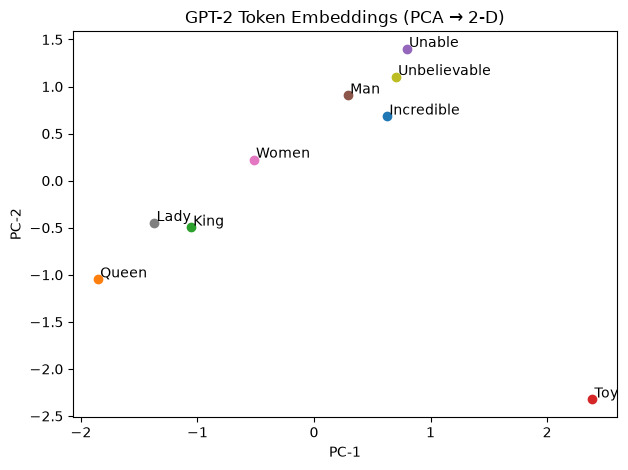

Incredible: [-0.079 -0.026  0.043 -0.106 -0.082]
Queen: [ 0.119 -0.138  0.236  0.006 -0.087]
 King: [ 0.102 -0.138  0.262 -0.051 -0.118]
  Toy: [ 0.333 -0.106  0.223 -0.105 -0.278]
Unable: [0.072 0.067 0.067 0.044 0.056]
  Man: [-0.028 -0.056  0.065 -0.017 -0.081]
Women: [-0.024  0.12   0.035 -0.014  0.01 ]
 Lady: [ 0.017 -0.1    0.164 -0.202  0.073]
Unbelievable: [0.032 0.024 0.097 0.028 0.036]


In [4]:
# !pip install torch transformers scikit-learn matplotlib --quiet

# =========================
# 1. Setup
# =========================
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA   # swap for TSNE if you prefer
from transformers import AutoTokenizer

#----- text examples ----------
# Text to tokenize
text = "Unbelievable!"

# Initialize GPT-2 tokenizer
tok = AutoTokenizer.from_pretrained("gpt2")

# Tokenize the text and print the tokens
# This will split the text into subword tokens that GPT-2 can understand
print(tok.tokenize(text))    # Output: ['Un', 'bel', 'iev', 'able', '!']
#------------------------------

# =========================
# 2. Load Model and Tokenizer
# =========================
model_name = "gpt2"                     # Model to be used

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(
    model_name,
    torch_dtype=torch.float16,          # keeps RAM low without hurting the embeddings
    low_cpu_mem_usage=True,
    ).eval()                            # Puts the model in evaluation mode

# =========================
# 3. Tokenize & Create vector embedding
# =========================
WORDS = ["Incredible", "Queen", "King", "Toy", "Unable", "Man", "Women", "Lady", "Unbelievable"]        # Words to be tokenised

embed_vectors = []
for word in WORDS:
    ids          = tok(word, add_special_tokens=False)["input_ids"]
    ids_t        = torch.tensor(ids).unsqueeze(0)         # shape: (1, tokens)
    with torch.no_grad():
        token_vecs = model.get_input_embeddings()(ids_t)  # shape: (1, tokens, 768)
    # Pool sub-word pieces → single 768-D vector (mean works fine for single words)
    embed_vectors.append(token_vecs.mean(dim=1).squeeze().cpu().numpy())

vecs = np.stack(embed_vectors)             # List -> Matrix | shape: (len(WORDS), 768)

# =========================
# 4. PCA (Reduce to 2-D) & Visualisation
# =========================

coords = PCA(n_components=2, random_state=0).fit_transform(vecs)

plt.figure()
for (x, y), label in zip(coords, WORDS):
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, label)
plt.title("GPT-2 Token Embeddings (PCA → 2-D)")
plt.xlabel("PC-1");  plt.ylabel("PC-2");  plt.tight_layout();  plt.show()

# Print the first few dimensions of the vectors
for w, v in zip(WORDS, vecs):
    print(f"{w:>5}: {np.round(v[:5], 3)}")

In [5]:
import torch

# Define sequence length and embedding dimension
seq_len, d_model = 10, 8  # seq_len: number of positions, d_model: embedding dimension

# Create position indices tensor of shape (seq_len, 1)
pos = torch.arange(seq_len).unsqueeze(1)  # [[0], [1], [2], ..., [9]]

# Create dimension indices for even dimensions: [0, 2, 4, 6]
idx = torch.arange(0, d_model, 2)

# Calculate frequency/angle rates for each dimension
# As idx/d_model increases, 10000^(idx/d_model) increases exponentially
# This creates frequencies that vary from high (small idx) to low (large idx)
angle_rates = 1 / (10000 ** (idx / d_model))

# Initialize positional encoding matrix of shape (seq_len, d_model)
pe = torch.zeros(seq_len, d_model)

# Fill even indices with sine and odd indices with cosine
# pos * angle_rates creates a matrix of angles by broadcasting
pe[:, 0::2] = torch.sin(pos * angle_rates)  # sin for even dimensions (0,2,4,6)
pe[:, 1::2] = torch.cos(pos * angle_rates)  # cos for odd dimensions (1,3,5,7)

pe

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00],
        [-7.5680e-01, -6.5364e-01,  3.8942e-01,  9.2106e-01,  3.9989e-02,
          9.9920e-01,  4.0000e-03,  9.9999e-01],
        [-9.5892e-01,  2.8366e-01,  4.7943e-01,  8.7758e-01,  4.9979e-02,
          9.9875e-01,  5.0000e-03,  9.9999e-01],
        [-2.7942e-01,  9.6017e-01,  5.6464e-01,  8.2534e-01,  5.9964e-02,
          9.9820e-01,  6.0000e-03,  9.9998e-01],
        [ 6.5699e-01,  7.5390e-01,  6.4422e-01,  7.6484e-01,  6.9943e-02,
          9.9755e-01,  6.9999e-03,  9.9998e-01],
        [ 9.8936

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F

# Initialize model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

# Print total number of tokens in GPT-2's vocabulary
print("GPT-2 vocab size:", tokenizer.vocab_size) # (should be 50257)

# Get vocabulary as list of (token, id) tuples and shuffle randomly
vocab_items = list(tokenizer.get_vocab().items())
np.random.shuffle(vocab_items)

# Print first 10 random token-ID pairs from vocabulary
# Token is displayed with repr() to show special characters/whitespace
print("\nSample of token→ID mappings:")
for token, idx in vocab_items[:10]:
    print(f"{idx:5d} → {repr(token)}")

# Input text to predict next token for
text = "Hello, how are you"

# Tokenize input
inputs = tokenizer(text, return_tensors="pt")

# Get model predictions
with torch.no_grad():  # No need to track gradients for inference
    outputs = model(**inputs)

# Get logits for last token
logits = outputs.logits[:, -1, :]  # Shape: [batch_size, vocab_size] -> torch.Size([1, 50257]) in this case

# Get raw logits for top 5 tokens before softmax
top_k = 5
top_logits, top_indices = torch.topk(logits[0], top_k)

# Convert logits to probabilities using softmax
probs = F.softmax(logits, dim=-1)

# Get top 5 probabilities after softmax
top_probs = probs[0][top_indices]

print(f"\nTop {top_k} predictions for next token after '{text}':")
print("-" * 50)
print("Raw Logits vs Softmax Probabilities")
print("-" * 50)
for logit, prob, idx in zip(top_logits, top_probs, top_indices):
    token = tokenizer.decode([idx])
    print(f"Token ID: {idx} | Token: {token:10} | Logit: {logit:.4f} | Probability: {prob:.4f}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13247.62it/s]

GPT-2 vocab size: 50257

Sample of token→ID mappings:
17284 → 'ĠValent'
 3847 → 'night'
39338 → 'AIDS'
  413 → 'ew'
39163 → 'England'
20354 → 'Ġpools'
33616 → 'Foreign'
12437 → 'Ġshops'
22154 → 'Ġpanc'
16514 → 'tim'

Top 5 predictions for next token after 'Hello, how are you':
--------------------------------------------------
Raw Logits vs Softmax Probabilities
--------------------------------------------------
Token ID: 1804 | Token:  doing     | Logit: -93.1169 | Probability: 0.2651
Token ID: 30 | Token: ?          | Logit: -93.6844 | Probability: 0.1503
Token ID: 4203 | Token:  feeling   | Logit: -93.7024 | Probability: 0.1476
Token ID: 1701 | Token: ?"         | Logit: -94.3398 | Probability: 0.0780
Token ID: 11 | Token: ,          | Logit: -95.1794 | Probability: 0.0337


----
# Homework

1. สร้างประโยคใหม่ "I am good at anwsering questions and I can take the test and pass the finance exam." จงนำ Contextual sentences แปลงเป็น Embeddings (ด้วยวิธีใดก็ได้) และให้คะแนนความคล้าย (Similarity score) ด้วยการวัดแบบ Euclidean และ Cosine similarity

คำอ้างอิง = "concern"?



2. นำประโยคเพียง "I am good at anwsering questions and I can take the test and pass the finance" ไปทำแปลงผ่าน Autotokenizer เป็น Embedding vectors ด้วยโมเดล GPT-2 และสร้างคำใหม่ผ่าน GPT-2 เช่นกัน ผลลัพธ์ที่ได้เป็นคำใดต่อไปใน 10 อันดับแรกของการทำนาย (Top-10) มีความน่าจะเป็นเท่าใด

In [14]:
sentence = "I am good at anwsering questions and I can take the test and pass the finance exam."

contextual_sentences = [
	"I",
	"am good",
	"answering questions",
	"take the test",
	"pass the finance exam",
	sentence,
]
reference_word = "concern"

st_model_hw1 = SentenceTransformer('gpt2')
if st_model_hw1.tokenizer.pad_token is None:
	st_model_hw1.tokenizer.pad_token = st_model_hw1.tokenizer.eos_token

df_hw1 = pd.DataFrame(contextual_sentences, columns=["contextual_sentence"])
df_hw1["reference_word"] = reference_word

embeddings_hw1 = {text: st_model_hw1.encode(text) for text in contextual_sentences + [reference_word]}

df_hw1["cosine_similarity"] = df_hw1.apply(
	lambda r: cosine_similarity(embeddings_hw1[r.contextual_sentence], embeddings_hw1[r.reference_word]), axis=1
)
df_hw1["euclidean_distance"] = df_hw1.apply(
	lambda r: euclidean_distance(embeddings_hw1[r.contextual_sentence], embeddings_hw1[r.reference_word]), axis=1
)

print(df_hw1)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14155.73it/s]


                                 contextual_sentence reference_word  \
0                                                  I        concern   
1                                            am good        concern   
2                                answering questions        concern   
3                                      take the test        concern   
4                              pass the finance exam        concern   
5  I am good at anwsering questions and I can tak...        concern   

   cosine_similarity  euclidean_distance  
0           0.975663           33.422363  
1           0.994855           21.011230  
2           0.990205           70.390503  
3           0.986826           61.168484  
4           0.989685           72.058144  
5           0.984016          151.080673  


2. นำประโยคเพียง "I am good at anwsering questions and I can take the test and pass the finance" ไปทำแปลงผ่าน Autotokenizer เป็น Embedding vectors ด้วยโมเดล GPT-2 และสร้างคำใหม่ผ่าน GPT-2 เช่นกัน ผลลัพธ์ที่ได้เป็นคำใดต่อไปใน 10 อันดับแรกของการทำนาย (Top-10) มีความน่าจะเป็นเท่าใด

In [15]:
text_hw2 = "I am good at anwsering questions and I can take the test and pass the finance"

tok_hw2 = AutoTokenizer.from_pretrained("gpt2")
embed_model_hw2 = AutoModel.from_pretrained(
	"gpt2", torch_dtype=torch.float16, low_cpu_mem_usage=True
).eval()

enc_hw2 = tok_hw2(text_hw2, return_tensors="pt")
token_strs_hw2 = tok_hw2.convert_ids_to_tokens(enc_hw2["input_ids"][0])

print("Tokens:", token_strs_hw2)
print("Token IDs:", enc_hw2["input_ids"][0].tolist())

with torch.no_grad():
	embedding_vectors_hw2 = embed_model_hw2.get_input_embeddings()(enc_hw2["input_ids"])  # (1, seq_len, 768)

print("\nEmbedding vectors shape:", embedding_vectors_hw2.shape)
for token, vec in zip(token_strs_hw2, embedding_vectors_hw2[0]):
	print(f"{token!r:>15}: {vec[:5].float().numpy().round(3)} ...")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3021.14it/s]

Tokens: ['I', 'Ġam', 'Ġgood', 'Ġat', 'Ġan', 'ws', 'ering', 'Ġquestions', 'Ġand', 'ĠI', 'Ġcan', 'Ġtake', 'Ġthe', 'Ġtest', 'Ġand', 'Ġpass', 'Ġthe', 'Ġfinance']
Token IDs: [40, 716, 922, 379, 281, 18504, 1586, 2683, 290, 314, 460, 1011, 262, 1332, 290, 1208, 262, 9604]

Embedding vectors shape: torch.Size([1, 18, 768])
            'I': [ 0.147 -0.096  0.143 -0.106 -0.012] ...
          'Ġam': [ 0.16  -0.125  0.115 -0.033 -0.053] ...
        'Ġgood': [-0.084 -0.051  0.037 -0.184  0.081] ...
          'Ġat': [0.088 0.054 0.032 0.005 0.028] ...
          'Ġan': [-0.087 -0.012  0.069 -0.072 -0.075] ...
           'ws': [-0.009 -0.3    0.268  0.084 -0.042] ...
        'ering': [-0.135 -0.271  0.239  0.096  0.111] ...
   'Ġquestions': [ 0.133  0.033  0.134 -0.211 -0.224] ...
         'Ġand': [-0.053 -0.001  0.03   0.022  0.025] ...
           'ĠI': [ 0.091 -0.036  0.083  0.    -0.095] ...
         'Ġcan': [-0.025  0.113  0.043  0.084 -0.178] ...
        'Ġtake': [ 0.036 -0.079  0.117 -0.072 -0.

In [16]:
inputs_hw2 = tokenizer(text_hw2, return_tensors="pt")

with torch.no_grad():
	outputs_hw2 = model(**inputs_hw2)

logits_hw2 = outputs_hw2.logits[:, -1, :]
probs_hw2 = F.softmax(logits_hw2, dim=-1)

top_k = 10
top_logits_hw2, top_indices_hw2 = torch.topk(logits_hw2[0], top_k)
top_probs_hw2 = probs_hw2[0][top_indices_hw2]

print(f"Top {top_k} predictions for the next token after:\n'{text_hw2}'")
print("-" * 60)
for rank, (logit, prob, idx) in enumerate(zip(top_logits_hw2, top_probs_hw2, top_indices_hw2), start=1):
	token = tokenizer.decode([idx])
	print(f"{rank:2d}. Token ID: {idx.item():6d} | Token: {token!r:12} | Logit: {logit:.4f} | Probability: {prob:.4%}")

Top 10 predictions for the next token after:
'I am good at anwsering questions and I can take the test and pass the finance'
------------------------------------------------------------
 1. Token ID:   1332 | Token: ' test'      | Logit: -105.2022 | Probability: 42.6761%
 2. Token ID:   2814 | Token: ' exam'      | Logit: -107.0941 | Probability: 6.4350%
 3. Token ID:     13 | Token: '.'          | Logit: -107.2580 | Probability: 5.4622%
 4. Token ID:   1808 | Token: ' question'  | Logit: -107.6953 | Probability: 3.5276%
 5. Token ID:   5254 | Token: ' tests'     | Logit: -108.0185 | Probability: 2.5532%
 6. Token ID:   2683 | Token: ' questions' | Logit: -108.4776 | Probability: 1.6133%
 7. Token ID:   1781 | Token: ' course'    | Logit: -108.7896 | Probability: 1.1809%
 8. Token ID:    290 | Token: ' and'       | Logit: -108.9366 | Probability: 1.0195%
 9. Token ID:   2198 | Token: ' check'     | Logit: -108.9423 | Probability: 1.0137%
10. Token ID:  26420 | Token: ' exams'     | Log